# The best bus14 encoders, retrained on WCCI

`transfer_story.ipynb` asks whether weights trained on `bus14` carry onto the
36-substation WCCI grid. This notebook asks the question underneath it, which
transfer cannot answer on its own:

> **Can WCCI be learned at all by the architectures that learned bus14 best —
> given a full training budget on WCCI itself?**

Nothing is transferred here. Screens A–D picked five encoders on `bus14`; each
was re-instantiated with byte-identical encoder and training blocks, pointed at
`bus36_wcci_nomaint`, and trained **from random initialisation for 15M steps**.
Only three things changed from the bus14 config: `env_id`, the reduced action
space, and the run name.

One consequence of that faithfulness matters more than any other and is the
reason this notebook exists separately. These encoders use the `bus` and
`heterogeneous` graph schemas, which `common/action_metadata.py` will not pair
with candidate-action pooling — so every cell here uses
`actor_action_head = "mlp"` over the reduced action list, exactly as the bus14
screens did. **The transfer line uses the shared candidate scorer instead.** So
these runs and the `cas_hl` line differ in their action head, and section 4 turns
that accident into the most informative comparison available.

The reference frame is identical to the transfer notebooks: 50 held-out chronics,
split into the **24 difficult** ones do-nothing loses and the **26 easy** ones it
already survives, with the one-step greedy oracle as the ceiling at each cap.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd()))
import wcci_transfer_data as W

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

data = W.load()
wsc = W.load_wsc(data)
runs, episodes = wsc.runs, wsc.episodes
DN_HARD, DN_OVERALL = data.dn_hard, data.dn_overall
N_HARD, N_EASY = data.n_hard, data.n_easy
EXPORT_DIR = data.export_dir / "best_bus14_to_wcci_story"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    fig.savefig(EXPORT_DIR / f"{stem}.png", dpi=170, bbox_inches="tight")


# Two checkpoints per cell: the best-test snapshot and the final one. Sections 1
# to 4 use the final checkpoints — the full-budget models — and section 1b
# compares the two directly.
final = runs.loc[runs["checkpoint_kind"] == "final"]
best_test = runs.loc[runs["checkpoint_kind"] == "best test"]
SCHEMA_ORDER = (
    final.groupby("schema")["hard_pct"].mean().sort_values(ascending=False).index.tolist()
)
CAPS = sorted(runs["mk"].unique())

display(Markdown(
    f"**{len(runs)} verified evaluations** — {final['schema'].nunique()} encoders x "
    f"{len(CAPS)} action caps ({', '.join(f'mk{c}' for c in CAPS)}) x "
    f"{{best-test, final}} checkpoints, all reproducing their own artifacts.  \n"
    f"The final checkpoints all sit at **{int(final['checkpoint_step'].max()):,}** WCCI "
    f"steps — the full 15M budget.  \n"
    f"Reference: do-nothing scores **{DN_OVERALL:.2f}%** overall and "
    f"**{DN_HARD:.2f}%** on the {N_HARD} difficult chronics."
))

**16 verified evaluations** — 4 encoders x 2 action caps (mk64, mk256) x {best-test, final} checkpoints, all reproducing their own artifacts.  
The final checkpoints all sit at **14,971,392** WCCI steps — the full 15M budget.  
Reference: do-nothing scores **56.00%** overall and **8.34%** on the 24 difficult chronics.

## 0. A collision that had to be fixed first

Each encoder was originally evaluated twice — once from its **best-test**
checkpoint and once from its **final** one — and both evaluations were written
into the *same* action-log directory. The second overwrote the first's
per-episode CSV, so eight of the sixteen result JSONs pointed at episodes that
were not theirs.

The loader checks for exactly this, the same way the transfer digest does: an
artifact is accepted only if the episodes on disk reproduce the survival number
stored in that run's own JSON. On the first pass it rejected eight of sixteen.
Those evaluations have since been re-run into distinct log directories, and the
table below is the check passing on all of them.

Worth keeping as a rule: **never let `--action-log-dir` default when the same
checkpoint is evaluated more than once.** Two evaluations that differ only in a
gate threshold or a checkpoint selection will otherwise silently share one set
of episodes, and the survival number in the JSON stays plausible while the
per-episode data underneath belongs to the other run.

In [2]:
display(Markdown(
    f"#### Artifact verification: **{len(runs)} accepted, {len(wsc.rejected)} rejected**"
))
display(
    runs[["run", "checkpoint_kind", "schema_label", "mk", "checkpoint_step",
          "overall_pct", "hard_pct", "hard_rescues", "easy_kept"]]
    .sort_values(["schema_label", "mk", "checkpoint_kind"])
)
if len(wsc.rejected):
    display(wsc.rejected[["run", "reason"]])

#### Artifact verification: **16 accepted, 0 rejected**

,run,checkpoint_kind,schema_label,mk,checkpoint_step,overall_pct,hard_pct,hard_rescues,easy_kept
3,best_test_wsc_bus_e1n0v0_mk64_s0,best test,busbar + same-substation edges,64,14681088,37.94,5.10,0.00,12.00
11,wsc_bus_e1n0v0_mk64_s0,final,busbar + same-substation edges,64,14971392,39.63,5.15,0.00,9.00
2,best_test_wsc_bus_e1n0v0_mk256_s0,best test,busbar + same-substation edges,256,14266368,26.54,4.24,0.00,7.00
10,wsc_bus_e1n0v0_mk256_s0,final,busbar + same-substation edges,256,14971392,20.63,4.64,0.00,2.00
1,best_test_wsc_bus_e0n0v0_mk64_s0,best test,"busbar, no augmentation",64,4976640,20.05,3.55,0.00,2.00
9,wsc_bus_e0n0v0_mk64_s0,final,"busbar, no augmentation",64,14971392,29.47,4.50,0.00,4.00
0,best_test_wsc_bus_e0n0v0_mk256_s0,best test,"busbar, no augmentation",256,14266368,33.35,4.58,0.00,7.00
8,wsc_bus_e0n0v0_mk256_s0,final,"busbar, no augmentation",256,14971392,33.67,3.90,0.00,6.00
7,best_test_wsc_het_gbi_lbi_mk64_s0,best test,"disaggregated, both bidirectional",64,1658880,51.35,7.21,0.00,21.00
15,wsc_het_gbi_lbi_mk64_s0,final,"disaggregated, both bidirectional",64,14971392,44.95,6.80,0.00,15.00


## 1. None of them clears the bar

The bar is do-nothing. On the difficult cohort it scores 8.34 %, and the greedy
oracle shows what the same action set makes reachable.

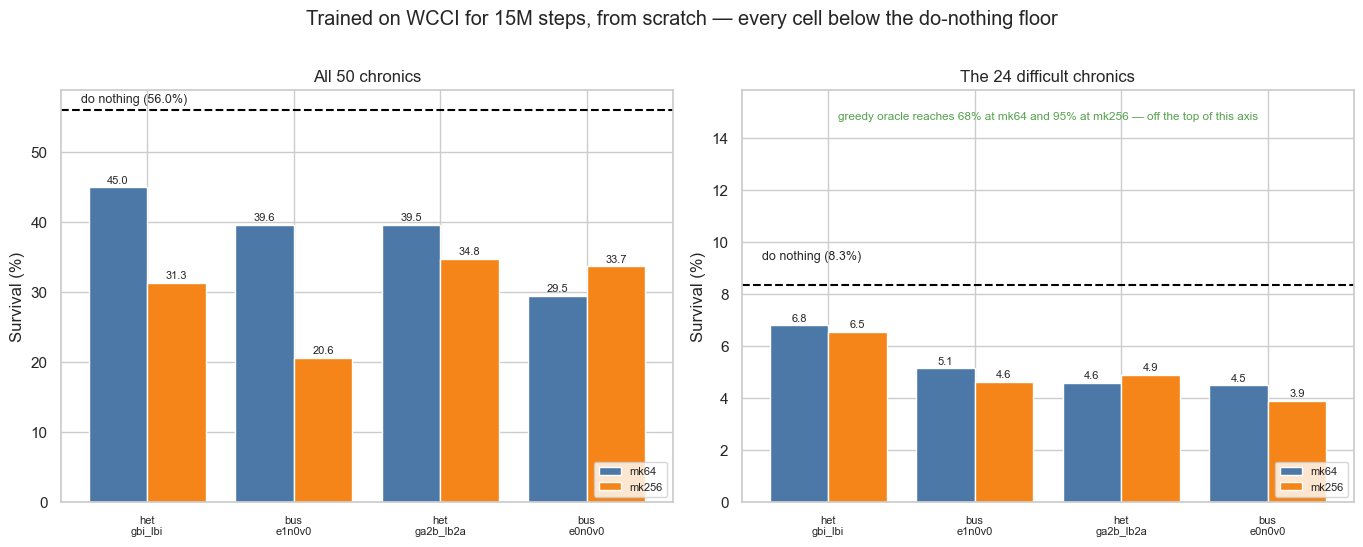

Final checkpoints, and — in the last column — all 16 evaluations including the best-test ones:

| | above do-nothing | best | median | rescues | all 16 above floor |
|---|---|---|---|---|---|
| all 50 chronics | **0 of 8** | 44.95% | 34.22% | — | **0 of 16** |
| 24 difficult | **0 of 8** | 6.80% | 4.77% | **0** of 24 | **0 of 16** |

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.4))
CAP_COLORS = {64: "#4C78A8", 256: "#F58518"}

for ax, (column, floor, title) in zip(axes, [
    ("overall_pct", DN_OVERALL, f"All {N_HARD + N_EASY} chronics"),
    ("hard_pct", DN_HARD, f"The {N_HARD} difficult chronics"),
]):
    width = 0.8 / len(CAPS)
    offsets = (np.arange(len(CAPS)) - (len(CAPS) - 1) / 2) * width
    for offset, cap in zip(offsets, CAPS):
        heights = [
            float(final.loc[(final["schema"] == s) & (final["mk"] == cap), column].iloc[0])
            if len(final.loc[(final["schema"] == s) & (final["mk"] == cap)]) else np.nan
            for s in SCHEMA_ORDER
        ]
        bars = ax.bar(np.arange(len(SCHEMA_ORDER)) + offset, heights, width=width,
                      color=CAP_COLORS[cap], edgecolor="white", linewidth=1.0,
                      label=f"mk{cap}")
        for bar, h in zip(bars, heights):
            ax.annotate(f"{h:.1f}", (bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
    ax.axhline(floor, color="black", linestyle="--", linewidth=1.5)
    ax.text(-0.45, floor + 1.0, f"do nothing ({floor:.1f}%)", ha="left", fontsize=9)
    if column == "hard_pct":
        ax.set_ylim(0, max(final["hard_pct"].max(), DN_HARD) * 1.9)
        ax.annotate(
            f"greedy oracle reaches {data.greedy_hard[64]:.0f}% at mk64 and "
            f"{data.greedy_hard[256]:.0f}% at mk256 — off the top of this axis",
            (0.5, 0.93), xycoords="axes fraction", ha="center", fontsize=8.5,
            color="#54A24B",
        )
    ax.set_xticks(np.arange(len(SCHEMA_ORDER)),
                  [s.replace("_", "\n", 1) for s in SCHEMA_ORDER], fontsize=8)
    ax.set(ylabel="Survival (%)", title=title)
    ax.legend(fontsize=8, loc="lower right")
fig.suptitle("Trained on WCCI for 15M steps, from scratch — every cell below the "
             "do-nothing floor", y=1.01)
fig.tight_layout()
save_figure(fig, "01_the_bar")
plt.show()

display(Markdown(
    f"Final checkpoints, and — in the last column — all {len(runs)} evaluations including "
    f"the best-test ones:\n\n"
    f"| | above do-nothing | best | median | rescues | all {len(runs)} above floor |\n"
    f"|---|---|---|---|---|---|\n"
    f"| all 50 chronics | **{int((final['overall_pct'] > DN_OVERALL).sum())} of {len(final)}** | "
    f"{final['overall_pct'].max():.2f}% | {final['overall_pct'].median():.2f}% | — | "
    f"**{int((runs['overall_pct'] > DN_OVERALL).sum())} of {len(runs)}** |\n"
    f"| {N_HARD} difficult | **{int((final['hard_pct'] > DN_HARD).sum())} of {len(final)}** | "
    f"{final['hard_pct'].max():.2f}% | {final['hard_pct'].median():.2f}% | "
    f"**{int(final['hard_rescues'].max())}** of {N_HARD} | "
    f"**{int((runs['hard_pct'] > DN_HARD).sum())} of {len(runs)}** |"
))

### What this says

**Not one of the sixteen beats doing nothing, on either cohort.** Among the
final checkpoints the best overall score is 44.95 % against a floor of 56.00 %,
and the best difficult-cohort score is 6.80 % against 8.34 %. Adding the
best-test checkpoints moves the ceiling to 51.35 % and 7.21 % — still short on
both. Not a single one of the 24 difficult chronics is carried to the end by any
of the sixteen runs: the rescue count is **0** everywhere, where the
transferred-and-fine-tuned models manage 4.

Headroom capture is negative in every cell, from −2.1 % to −6.5 %. That is not a
policy that underperforms; it is a policy that is worse than the absence of one.

## 1b. Best-test or final? And what "best test" is actually selecting

Now that both checkpoints of every cell verify, the two can be compared
directly. The question matters beyond bookkeeping: `best_test` is chosen on
overall test survival during training, and this dataset is unusually good at
showing what that criterion buys.

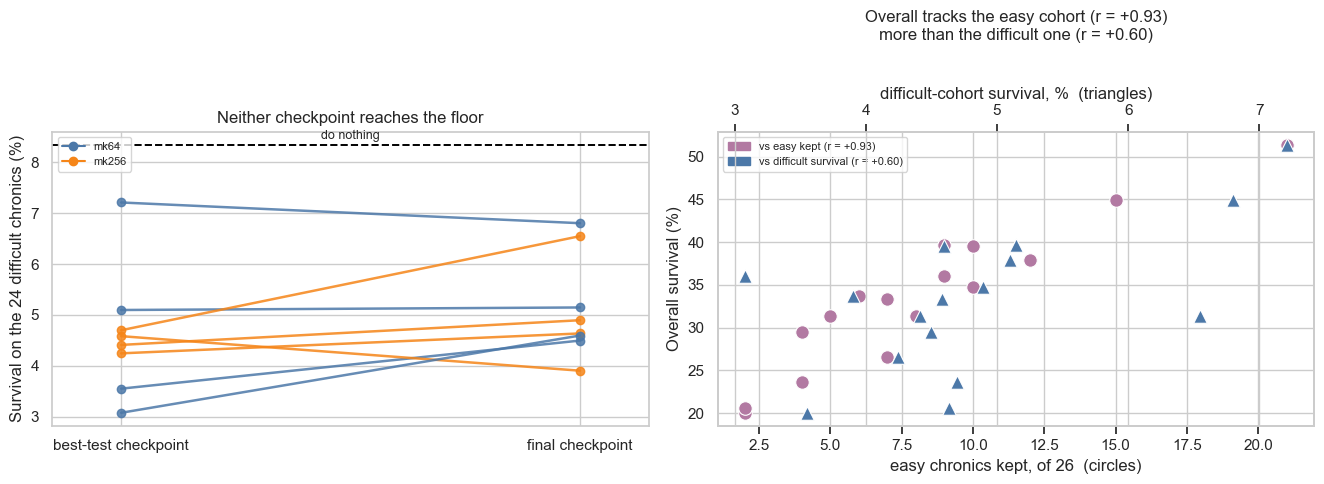

,metric,cells,best_test_minus_final,ci_low,ci_high,best_test_wins
0,hard_pct,8,-0.52,-1.10,0.04,2
1,overall_pct,8,-1.72,-5.31,2.07,2
2,easy_kept,8,1.12,-0.88,3.25,4


easy_kept        hard_pct       overall_pct      
checkpoint_kind   best test final best test final   best test final
schema        mk                                                   
bus_e0n0v0    64       2.00  4.00      3.55  4.50       20.05 29.47
              256      7.00  6.00      4.58  3.90       33.35 33.67
bus_e1n0v0    64      12.00  9.00      5.10  5.15       37.94 39.63
              256      7.00  2.00      4.24  4.64       26.54 20.63
het_ga2b_lb2a 64       9.00 10.00      3.08  4.59       36.05 39.54
              256      8.00 10.00      4.41  4.90       31.31 34.78
het_gbi_lbi   64      21.00 15.00      7.21  6.80       51.35 44.95
              256      4.00  5.00      4.70  6.55       23.62 31.32

In [4]:
paired = runs.pivot_table(index=["schema", "mk"], columns="checkpoint_kind",
                          values=["hard_pct", "overall_pct", "easy_kept"])
contrasts = []
for metric in ["hard_pct", "overall_pct", "easy_kept"]:
    delta = (paired[metric]["best test"] - paired[metric]["final"]).dropna()
    mean_d, lo, hi = W.paired_bootstrap(delta)
    contrasts.append({"metric": metric, "cells": len(delta),
                      "best_test_minus_final": mean_d, "ci_low": lo, "ci_high": hi,
                      "best_test_wins": int((delta > 0).sum())})

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.0))

for (schema, mk), row in paired.iterrows():
    axes[0].plot([0, 1], [row[("hard_pct", "best test")], row[("hard_pct", "final")]],
                 marker="o", linewidth=1.8, color=CAP_COLORS[mk], alpha=0.85)
axes[0].axhline(DN_HARD, color="black", linestyle="--", linewidth=1.4)
axes[0].text(0.5, DN_HARD + 0.12, "do nothing", ha="center", fontsize=9)
axes[0].set(xlim=(-0.15, 1.15), xticks=[0, 1],
            xticklabels=["best-test checkpoint", "final checkpoint"],
            ylabel=f"Survival on the {N_HARD} difficult chronics (%)",
            title="Neither checkpoint reaches the floor")
axes[0].legend(handles=[plt.Line2D([], [], color=CAP_COLORS[c], marker="o", label=f"mk{c}")
                        for c in CAPS], fontsize=8, loc="upper left")

r_easy = runs["overall_pct"].corr(runs["easy_kept"])
r_hard = runs["overall_pct"].corr(runs["hard_pct"])
twin = axes[1].twiny()
axes[1].scatter(runs["easy_kept"], runs["overall_pct"], s=95, color="#B279A2",
                edgecolor="white", linewidth=0.8)
twin.scatter(runs["hard_pct"], runs["overall_pct"], s=95, color="#4C78A8", marker="^",
             edgecolor="white", linewidth=0.8)
axes[1].set(xlabel=f"easy chronics kept, of {N_EASY}  (circles)", ylabel="Overall survival (%)")
twin.set_xlabel("difficult-cohort survival, %  (triangles)")
axes[1].set_title(f"Overall tracks the easy cohort (r = {r_easy:+.2f})\n"
                  f"more than the difficult one (r = {r_hard:+.2f})", pad=34)
axes[1].legend(handles=[
    Patch(color="#B279A2", label=f"vs easy kept (r = {r_easy:+.2f})"),
    Patch(color="#4C78A8", label=f"vs difficult survival (r = {r_hard:+.2f})"),
], fontsize=8, loc="upper left")
fig.tight_layout()
save_figure(fig, "01b_checkpoint_selection")
plt.show()

display(pd.DataFrame(contrasts))
display(paired.round(2))

### What this says

**The final checkpoint is the better one, slightly, and the "peaks early then
degrades" reading is wrong.** Across the eight cells the best-test checkpoint is
worth **−0.52 pp** on the difficult cohort, CI [−1.10, +0.04], winning only 2 of
8. On overall survival it is worse too, by 1.72 pp. Training to 15M does not
undo anything; it modestly helps.

The one cell that suggested otherwise is instructive rather than exceptional.
`het_gbi_lbi_mk64` picks its best-test checkpoint at **1.66M steps**, where it
scores 51.35 % overall — six and a half points above its own final checkpoint,
and the highest overall number in this notebook. On the difficult cohort that
same checkpoint is worth 7.21 % against the final's 6.80 %: an 0.4 pp edge behind
a 6.4 pp headline. Almost the whole difference is the easy cohort — 21 of 26
chronics kept at 1.66M against 15 at 15M.

That is the mechanism, and it generalises across all sixteen runs:

* overall survival correlates **+0.93** with the number of easy chronics kept;
* it correlates **+0.60** with difficult-cohort survival.

**Selecting a checkpoint on overall test survival is mostly selecting for not
breaking the free episodes.** For a policy already below the do-nothing floor
that means the criterion is rewarding inaction — a third instance of the pattern
this notebook keeps finding, after bus14 not predicting WCCI in section 3, and
overall not predicting difficult here.

## 2. How they fail

Survival percentages say a policy is bad. The episode data says *how*, and here
the answer is unambiguous: these models are not failing to rescue difficult
chronics, they are actively destroying easy ones.

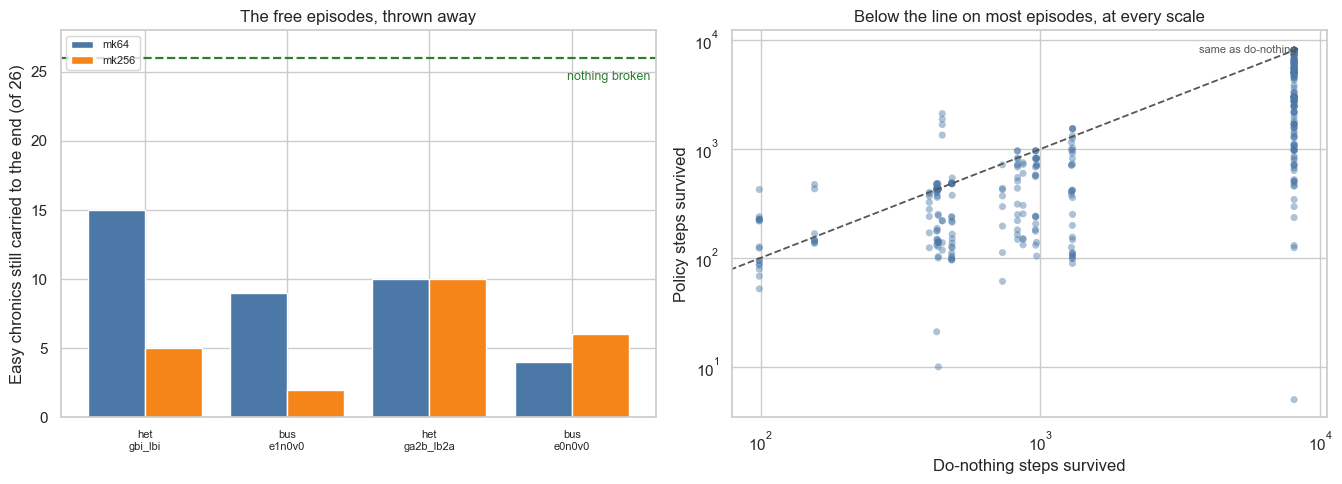

- Easy chronics: **147 of 208** episode-runs (71 %) are broken — chronics do-nothing carries to the end. The median run keeps **7.5 of 26**.
- Difficult chronics: **40 wins** against **149 losses** over 192 episode-runs.
- Mean steps survived **2761** against do-nothing's **4515** — they end episodes roughly **39 % sooner**.

In [5]:
# Restricted to the final checkpoints so no architecture is counted twice.
final_episodes = episodes.loc[episodes["key"].isin(set(final["key"]))]
easy = final_episodes.loc[~final_episodes["is_hard"]]
hard = final_episodes.loc[final_episodes["is_hard"]]

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.0))

kept = final.set_index(["schema", "mk"])["easy_kept"].unstack()
kept = kept.reindex(SCHEMA_ORDER)
width = 0.8 / len(CAPS)
offsets = (np.arange(len(CAPS)) - (len(CAPS) - 1) / 2) * width
for offset, cap in zip(offsets, CAPS):
    axes[0].bar(np.arange(len(SCHEMA_ORDER)) + offset, kept[cap], width=width,
                color=CAP_COLORS[cap], edgecolor="white", linewidth=1.0, label=f"mk{cap}")
axes[0].axhline(N_EASY, color="#2E7D32", linestyle="--", linewidth=1.6)
axes[0].text(len(SCHEMA_ORDER) - 0.45, N_EASY - 1.6, "nothing broken", ha="right",
             color="#2E7D32", fontsize=9)
axes[0].set_xticks(np.arange(len(SCHEMA_ORDER)),
                   [s.replace("_", "\n", 1) for s in SCHEMA_ORDER], fontsize=8)
axes[0].set(ylabel=f"Easy chronics still carried to the end (of {N_EASY})",
            ylim=(0, N_EASY + 2),
            title="The free episodes, thrown away")
axes[0].legend(fontsize=8, loc="upper left")

axes[1].scatter(final_episodes["dn_steps"], final_episodes["steps"], s=26, alpha=0.45,
                color="#4C78A8", edgecolor="none")
limit = max(final_episodes["dn_steps"].max(), final_episodes["steps"].max()) * 1.05
axes[1].plot([0, limit], [0, limit], color="#555555", linestyle="--", linewidth=1.3)
axes[1].text(limit * 0.97, limit * 0.9, "same as do-nothing", ha="right", fontsize=8,
             color="#555555")
axes[1].set(xscale="log", yscale="log", xlabel="Do-nothing steps survived",
            ylabel="Policy steps survived",
            title="Below the line on most episodes, at every scale")
fig.tight_layout()
save_figure(fig, "02_failure_mode")
plt.show()

display(Markdown(
    f"- Easy chronics: **{int((~easy['full_survival']).sum())} of {len(easy)}** episode-runs "
    f"({100 * (~easy['full_survival']).mean():.0f} %) are broken — chronics do-nothing "
    f"carries to the end. The median run keeps **{final['easy_kept'].median():.1f} of "
    f"{N_EASY}**.\n"
    f"- Difficult chronics: **{int((hard['delta_pp'] > 1e-9).sum())} wins** against "
    f"**{int((hard['delta_pp'] < -1e-9).sum())} losses** over {len(hard)} episode-runs.\n"
    f"- Mean steps survived **{final_episodes['steps'].mean():.0f}** against do-nothing's "
    f"**{final_episodes['dn_steps'].mean():.0f}** — they end episodes roughly "
    f"**{100 * (1 - final_episodes['steps'].mean() / final_episodes['dn_steps'].mean()):.0f} % sooner**."
))

## 3. Does bus14 skill predict WCCI learnability?

`transfer_story.ipynb` found that bus14 survival does not predict *transferred*
survival — r = −0.01 across sixteen architectures. That result is about frozen
weights, and the `X_wcci_scratch_arch` README is explicit that it should not be
assumed to carry over to retraining: a different question, a different mechanism.

So it is worth asking directly. Three of the four encoders here have a bus14
full-test number from the *corrected* screens; `het_gbi_lbi` has no corrected
bus14 rerun and the pre-correction number is not comparable, so it is left out
rather than substituted.

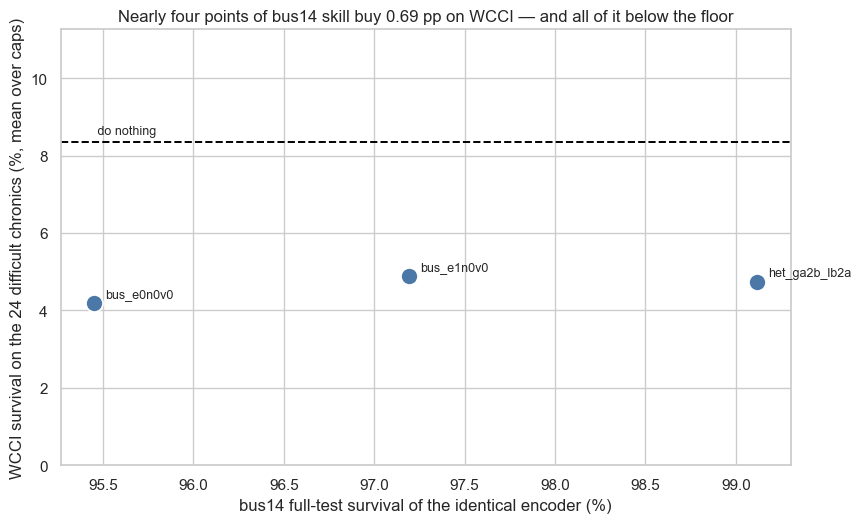

,schema,schema_label,bus14_pct,wcci_hard_mean,wcci_hard_best,wcci_overall_mean,caps
0,bus_e0n0v0,"busbar, no augmentation",95.45,4.20,4.50,31.57,2
1,bus_e1n0v0,busbar + same-substation edges,97.19,4.89,5.15,30.13,2
2,het_ga2b_lb2a,"disaggregated, gen a2b / load b2a",99.12,4.74,4.90,37.16,2


In [6]:
anchored = final.dropna(subset=["bus14_pct"])
link = (
    anchored.groupby(["schema", "schema_label", "bus14_pct"], as_index=False)
    .agg(wcci_hard_mean=("hard_pct", "mean"), wcci_hard_best=("hard_pct", "max"),
         wcci_overall_mean=("overall_pct", "mean"), caps=("mk", "nunique"))
    .sort_values("bus14_pct")
)

fig, ax = plt.subplots(figsize=(8.8, 5.4))
ax.scatter(link["bus14_pct"], link["wcci_hard_mean"], s=150, color="#4C78A8",
           edgecolor="white", linewidth=1.2, zorder=3)
for row in link.itertuples():
    ax.annotate(row.schema, (row.bus14_pct, row.wcci_hard_mean), xytext=(8, 4),
                textcoords="offset points", fontsize=9)
ax.axhline(DN_HARD, color="black", linestyle="--", linewidth=1.4)
ax.text(link["bus14_pct"].min(), DN_HARD + 0.15, " do nothing", fontsize=9, va="bottom")
span = link["wcci_hard_mean"].max() - link["wcci_hard_mean"].min()
ax.set(xlabel="bus14 full-test survival of the identical encoder (%)",
       ylabel=f"WCCI survival on the {N_HARD} difficult chronics (%, mean over caps)",
       ylim=(0, max(DN_HARD, link["wcci_hard_mean"].max()) * 1.35),
       title=f"Nearly four points of bus14 skill buy {span:.2f} pp on WCCI — "
             f"and all of it below the floor")
fig.tight_layout()
save_figure(fig, "03_bus14_vs_wcci")
plt.show()
display(link)

### What this says

**Three points cannot support a correlation, and none is needed.** Across a
bus14 range of 95.45 % to 99.12 % — the difference between a good encoder and
the best one Screen D produced — WCCI difficult-cohort survival moves from 4.20 %
to 4.89 %, and not monotonically: the best bus14 encoder (`het_ga2b_lb2a`,
99.12 %) lands *between* the other two on WCCI.

The unanchored fourth encoder makes the point sharper rather than weaker.
`het_gbi_lbi` is Screen D's **baseline** cell, the one `ga2b_lb2a` was supposed
to improve on — and it is the best of the four here, on both caps and both
cohorts. Whatever ranks these encoders on WCCI, it is not what ranked them on
bus14.

Taken with the transfer notebook's r = −0.01, the two results say the same thing
through different mechanisms: **bus14 is not a selection criterion for WCCI**,
whether the weights are carried over or thrown away.

## 4. The comparison that matters: the action head

The accident noted at the top — that these encoders cannot use candidate
pooling, so they fall back to an MLP head over the reduced action list — turns
out to be the most informative thing in this notebook.

At mk64, ungated, on the difficult cohort, four arms are directly comparable in
everything except two factors: **where the weights started**, and **what kind of
action head sits on top**.

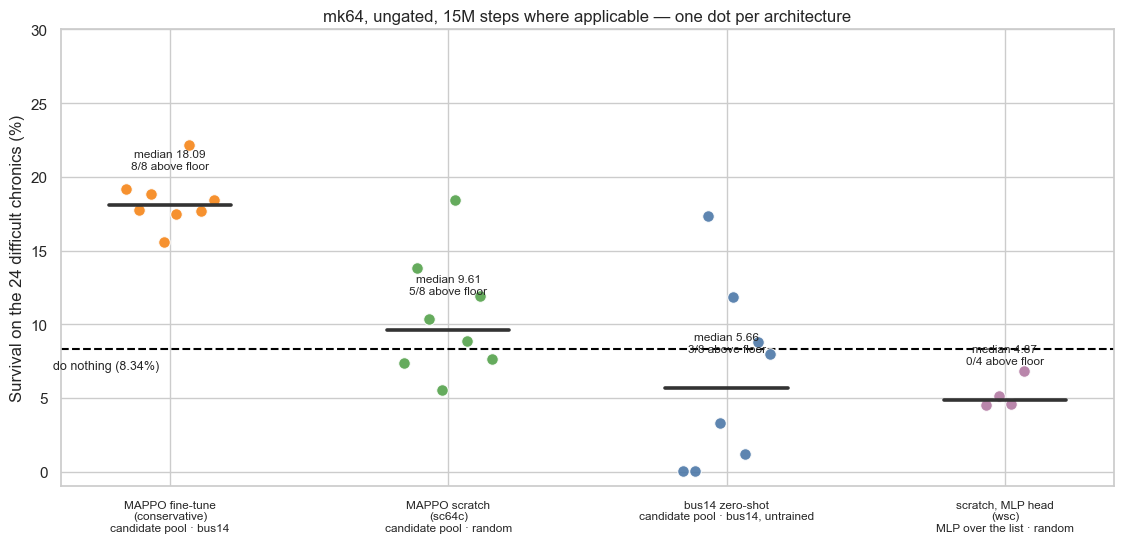

,arm,action head,initialisation,architectures,above_do_nothing,median_hard,best_hard,best_rescues,median_easy_kept
0,MAPPO fine-tune (conservative),candidate pool,bus14,8,8,18.09,22.14,4,25.50
1,MAPPO scratch (sc64c),candidate pool,random,8,5,9.61,18.46,2,16.00
2,bus14 zero-shot,candidate pool,"bus14, untrained",8,3,5.66,17.35,1,10.50
3,"scratch, MLP head (wsc)",MLP over the list,random,4,0,4.87,6.80,0,9.50


In [7]:
mk64 = final.loc[final["mk"] == 64]
cas = data.runs.loc[
    (data.runs["mk"] == 64) & (data.runs["gate"] == "ungated")
    & data.runs["variant"].str.startswith("NLS") & data.runs["hard_pct"].notna()
]
ARMS = [
    ("MAPPO fine-tune\n(conservative)", "candidate pool", "bus14",
     cas.loc[cas["route"] == "MAPPO fine-tune (conservative)"], "#F58518"),
    ("MAPPO scratch\n(sc64c)", "candidate pool", "random",
     cas.loc[cas["route"] == "MAPPO scratch"], "#54A24B"),
    ("bus14 zero-shot", "candidate pool", "bus14, untrained",
     cas.loc[cas["route"] == "bus14 zero-shot"], "#4C78A8"),
    ("scratch, MLP head\n(wsc)", "MLP over the list", "random", mk64, "#B279A2"),
]

fig, ax = plt.subplots(figsize=(11.4, 5.6))
for i, (label, head, init, frame, colour) in enumerate(ARMS):
    values = frame["hard_pct"].to_numpy()
    jitter = (np.arange(len(values)) - (len(values) - 1) / 2) * 0.045
    ax.scatter(np.full(len(values), i) + jitter, values, s=70, color=colour,
               edgecolor="white", linewidth=0.8, zorder=3, alpha=0.9)
    ax.plot([i - 0.22, i + 0.22], [np.median(values)] * 2, color="#333333",
            linewidth=2.6, zorder=4)
    ax.annotate(f"median {np.median(values):.2f}\n{int((values > DN_HARD).sum())}/"
                f"{len(values)} above floor", (i, np.median(values)),
                xytext=(0, 26), textcoords="offset points", ha="center", fontsize=8.5)
ax.axhline(DN_HARD, color="black", linestyle="--", linewidth=1.5)
ax.text(-0.42, DN_HARD - 1.4, f"do nothing ({DN_HARD:.2f}%)", ha="left", fontsize=9)
ax.set_xticks(range(len(ARMS)), [f"{a[0]}\n{a[1]} · {a[2]}" for a in ARMS], fontsize=8.5)
ax.set(ylabel=f"Survival on the {N_HARD} difficult chronics (%)",
       ylim=(-1, max(cas["hard_pct"].max(), 24) * 1.25),
       title="mk64, ungated, 15M steps where applicable — one dot per architecture")
fig.tight_layout()
save_figure(fig, "04_action_head")
plt.show()

rows = []
for label, head, init, frame, _ in ARMS:
    rows.append({
        "arm": label.replace("\n", " "), "action head": head, "initialisation": init,
        "architectures": len(frame),
        "above_do_nothing": int((frame["hard_pct"] > DN_HARD).sum()),
        "median_hard": frame["hard_pct"].median(), "best_hard": frame["hard_pct"].max(),
        "best_rescues": int(frame["hard_rescues"].max()),
        "median_easy_kept": frame["easy_kept"].median(),
    })
display(pd.DataFrame(rows))

### What this says

**The action head decides whether WCCI can be learned from scratch at all.**

Hold the initialisation fixed at random, the budget at 15M steps and the action
set at mk64, and swap only the head:

* **shared candidate scorer** (`sc64c`) — median 9.61 % on the difficult cohort,
  **5 of 8** architectures above the do-nothing floor, best 18.46 %, up to 2
  rescues;
* **MLP over the reduced list** (`wsc`) — median 4.87 %, **0 of 4** above the
  floor, best 6.80 %, **zero** rescues.

Same task, same budget, same candidate set, opposite outcome. The candidate
scorer conditions on each action's own embedding, so it can generalise across a
128-action set it has only partially explored; the MLP has one output per index
and has to learn all of them separately from the same 15M steps. On a
36-substation grid that is evidently too much to ask.

This also settles a reading the transfer notebook could not. Section 9 there
showed every `sc64c` from-scratch model landing below the do-nothing floor on
*overall* survival, which invited the conclusion that WCCI simply resists
from-scratch training. On the difficult cohort — now computable, since the
per-episode artifacts have been synced — that is too strong: `sc64c` clears the
floor in 5 of 8 cells. It is the **MLP head**, not WCCI, that fails outright.

And the ordering across all four arms is worth stating plainly, because it is
the whole argument of this line of work in one line:

> fine-tuned from bus14 (18.09) > from scratch with a candidate scorer (9.61)
> > do-nothing (8.34) > zero-shot transfer (5.66) > from scratch with an MLP head (4.87)

Transfer alone is not enough. Target training alone is barely enough. **The two
together are the only combination that clearly works**, and the architecture
that makes both possible is the shared candidate scorer.

## 5. What to run next

1. ~~Re-evaluate the eight rejected best-test checkpoints.~~ **Done** — all
   sixteen now verify, and section 1b is the result. The "peaks early then
   degrades" worry it was meant to settle turned out to be an artifact of
   selecting on overall survival.
2. **Get a corrected bus14 number for `het_gbi_lbi`.** It is the best encoder on
   WCCI and the only one with no comparable bus14 anchor, which is exactly the
   point where section 3 is weakest.
3. **Do not extend this screen.** Ten more cells of MLP-head from-scratch
   training will not clear the do-nothing floor; section 4 says the head is the
   binding constraint. If the question is "which encoder learns WCCI best", it
   should be asked with a candidate-pool head — which means the `bus` and
   `heterogeneous` schemas need `gnn_graph_type = "heterogeneous_line"` support
   in `common/action_metadata.py`, or the screen has to be re-expressed on the
   disaggregated line-node graph the `cas_hl` line already uses.

In [8]:
exports = {
    "wsc_runs.csv": runs.drop(columns=["episode_csv"], errors="ignore"),
    "wsc_rejected.csv": wsc.rejected.drop(columns=["episode_csv"], errors="ignore"),
    "checkpoint_selection.csv": pd.DataFrame(contrasts),
    "bus14_vs_wcci.csv": link,
    "action_head_comparison.csv": pd.DataFrame(rows),
}
for name, table in exports.items():
    table.to_csv(EXPORT_DIR / name, index=False)
print(f"{len(exports)} tables + 4 figures written to:\n{EXPORT_DIR}")

5 tables + 4 figures written to:
/Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/analysis/best_bus14_to_wcci_story
